# Code for "Simple Model" of W based on idealized forcing parameter F 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from firedrake import *
from scipy import integrate

%matplotlib widget

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


## Goal: Solve our simple model for values of w  
### Simple model is given as :   
$\frac{\partial^2 w}{\partial z^2} + \frac{4R}{\beta^2 L^4 H} S_0 w = - \frac{\beta L^2 H}{2R} \partial_z \mathcal{F}$

where all variables have been assumed to have a meridional structure $\exp(-y^2 / L^2)$

### Idealized Forcing term is given as: 
$\mathcal{F} (z, t) = f \exp(-\frac{\theta^2}{2\Delta\theta^2}) \exp(-\frac{(z - z_0)^2}{2 \Delta z^2}) \cos(mz + \omega t)$

then
$\frac{\partial \mathcal{F}}{\partial z} = F \exp(-\frac{(z-z_0)^2}{2\Delta z^2}) \left[ -\frac{z-z_0}{\Delta z^2} \cos(mz + \omega t) - m \sin(mz + \omega t)\right]$

### S0 is given as :   
$S_0 = \partial_z T_0 + \frac{g}{c_p}$   
with $\partial_z T_0 = 3 \times 10^{-3}$ approximated from ERA 5 output

# Constants and Units (dimensional analysis) 

Domain: $t = $ time in seconds, $z = $ height in metres

Global parameters:  
$a=6.37\cdot10^6$ m  
$\omega_e=7.29\cdot 10^{-5}$ rad s$^{-1}$  
$H=7$ km  
$R=287$ J kg$^{-1}$ K$^{-1}$  
$g= 9.81$ m s$^{-2}$   
$C_p=1005$ J kg$^{-1}$ K$^{-1}$  

QBO parameters: (defined explicitly below)
$L= 1100$ km  
$F=0.1$  m s$^{-1}$ day$^{-1}$  
$z0=30$ km      
$\Delta z=6$ km  
$m=\frac{2pi}{25}$ km$^{-1}$     
$\omega=\frac{2\pi}{840}$ day$^{-1}$  

# User defined parameters

In [2]:
# Start & end time (no. QBO periods)
t0 = 0
t1 = 5

# Bottom & top of the domain (z, km)
z0 = 5000
z1 = 50000

# Resolution (time in secs, height in m)
dt = 10 * 3600 * 24
dz = 450

# For saving plots
#plt_path='/Users/colleen/Documents/Working Papers/ISSI QBO/plots/'
plt_path='/home/cwp29/tmp/qosm/'

# Global parameters

In [3]:
a = 6371e3 # m 
H = 7e3 # m
R = 287 # J/(kg K)
Cp = 1005
g = 9.81
omega_e = 7.29e-5
beta = 2 * np.cos(0) * omega_e / a
S0 = 3e-3 + g/Cp

# QBO parameters

In [4]:
#setup constants : 
L = 1100e3 # m
dtheta = L / a 
QBO_F=0.1/24/3600 # m s-1 s-1 
QBO_dz=6e3# m 
QBO_z0=30e3 # m 
m=(2*np.pi)/(25*1000) #m -1 
QBO_T=840*3600*24 # days - cycle time for QBO  this is a constant 
QBO_omega=(np.pi*2)/QBO_T # per second [s-1] - this is a constant 

# Domain definition & forcing

In [5]:
# Domain arrays
ts = np.arange(t0*QBO_T, t1*QBO_T + dt, dt)
zs = np.arange(z0, z1+dz, dz)

Z, T = np.meshgrid(zs, ts)

F = QBO_F * np.exp(-np.power(Z-QBO_z0, 2) / (2 * np.power(QBO_dz, 2))) * np.cos(m*Z  + QBO_omega*T)


# Optional meridional structure for plotting
lats = np.arange(-20, 21, 1)
thetas = lats * np.pi / 180.

Zm, Lm = np.meshgrid(zs, lats)

merid_struct = np.exp(-np.power(thetas / dtheta, 2))
F_merid = merid_struct * F[:, :, np.newaxis]

# Generate Plots of Idealized Forcing

In [6]:
def zt_plot(plot_arr, vmin=None, vmax=None, save=False, save_title=None, cmap='viridis', title=None, cbar_title=None):
    fig = plt.figure()
    if (vmin is not None) and (vmax is not None):
        plt.pcolormesh(T/3600/24, Z/1e3, plot_arr, cmap=cmap, vmin=vmin, vmax=vmax)
    else:
        plt.pcolormesh(T/3600/24, Z/1e3, plot_arr, cmap=cmap)

    plt.xlabel('Time [day]')
    plt.ylabel('Altitude [km]')
    
    if title is not None:
        plt.title(title)

    if cbar_title is not None:
        plt.colorbar(label=cbar_title)

    if save:
        #plt.savefig(plt_path+'forcing_0N.pdf', bbox_inches='tight')
        from jfunctions import save_fig
        save_fig(fig, plt_path+save_title+'.png', dpi=300)

In [7]:
def zlat_plot(plot_arr, vmin=None, vmax=None, save=False, cmap='viridis', title=None, cbar_title=None):
    fig = plt.figure()
    if (vmin is not None) and (vmax is not None):
        plt.pcolormesh(Lm, Zm/1e3, plot_arr, cmap=cmap, vmin=vmin, vmax=vmax)
    else:
        plt.pcolormesh(Lm, Zm/1e3, plot_arr, cmap=cmap)

    plt.xlabel('Latitude [degrees]')
    plt.ylabel('Altitude [km]')
    
    if title is not None:
        plt.title(title)

    if cbar_title is not None:
        plt.colorbar(label=cbar_title)

    if save:
        #plt.savefig(plt_path+'forcing_0N.pdf', bbox_inches='tight')
        from jfunctions import save_fig
        save_fig(fig, plt_path+'forcing_0N.png', dpi=300)

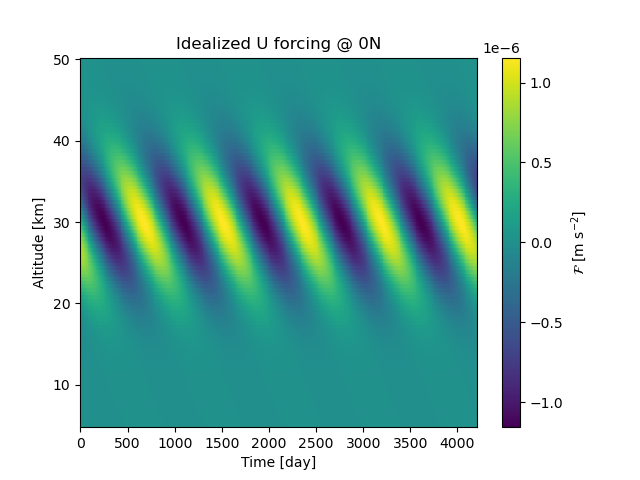

In [8]:
zt_plot(F, 
        title = 'Idealized U forcing @ 0N',
        cbar_title = '$\mathcal{F}$ [m s$^{-2}$]',
        save = True,
        save_title='forcing_0N'
       )

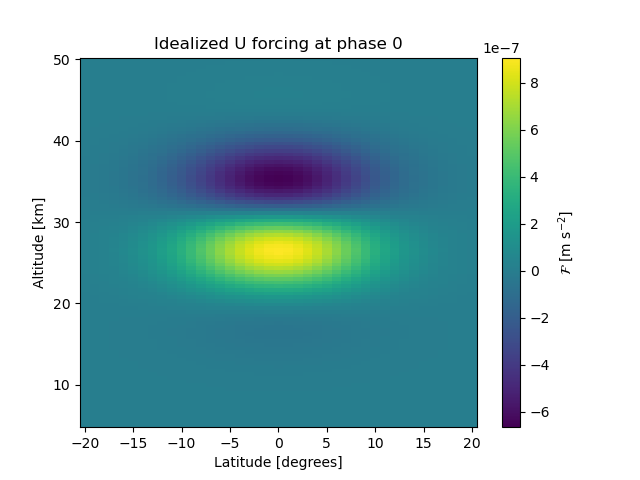

In [9]:
zlat_plot(F_merid[0, :, :].T, 
        title = 'Idealized U forcing at phase 0',
        cbar_title = '$\mathcal{F}$ [m s$^{-2}$]',
        save = True
       )

# Numerical solution using Firedrake

In [10]:
t=t0

N=10000 # firedrake number of elements

soln = np.zeros(shape=(len(zs), len(ts)))

for i in range(len(ts)):
    t = t0*QBO_T + dt * i
    
    # define your firedrake variables 
    F_f=firedrake.Constant(QBO_F) # m s-1 s-1
    dz_f=firedrake.Constant(QBO_dz) # m 
    z0_f=firedrake.Constant(QBO_z0) # m 
    m_f=firedrake.Constant(m) #m -1 
    omega_t=firedrake.Constant(QBO_omega*t) # s s-1

    H_f = firedrake.Constant(H)
    S0_f = firedrake.Constant(S0)
    C = beta * L * L / 2
    C_f = firedrake.Constant(C)
    R_f = firedrake.Constant(R)
    
    # setup firedrake parameters 
   
    mesh = IntervalMesh(N, z0, z1) #solving in function space z = 5 to 50 km 

    V = FunctionSpace(mesh,'CG', 1) # Define Function space as "continuous Galerkin" "Lagrange" or "CG", representing standard scalar
    #Lagrange finite elements (continuous piecewise polynomial functions);

    u = TrialFunction(V) # trial function 
    v = TestFunction(V) # test function 
    z = SpatialCoordinate(mesh)[0]

    # Define LHS : 
    LHS = (S0_f * R_f /(C_f*C_f*H_f)) * u * v * dx - inner(grad(u), grad(v)) * dx

    # Define RHS : 
    dFdz = F_f*exp(-(z-z0_f)**2 / (2*(dz_f**2))) * (-((z-z0_f)/(dz_f**2))*cos(m_f*z + omega_t) - m_f*sin(m_f*z + omega_t))
    RHS = -(C_f*H_f/R_f) * dFdz * v * dx
    s=Function(V)

    # for Neumann at lower boundary
    #bcs =  [DirichletBC(V, Constant(0), 2)]
    
    # for Dirichlet at both boundaries
    bcs =  [DirichletBC(V, Constant(0), 1),
            DirichletBC(V, Constant(0), 2)]

    # firedrake solve
    solve(LHS==RHS, s, bcs=bcs)
        
    # store result
    soln[:,i]=s.at(zs)

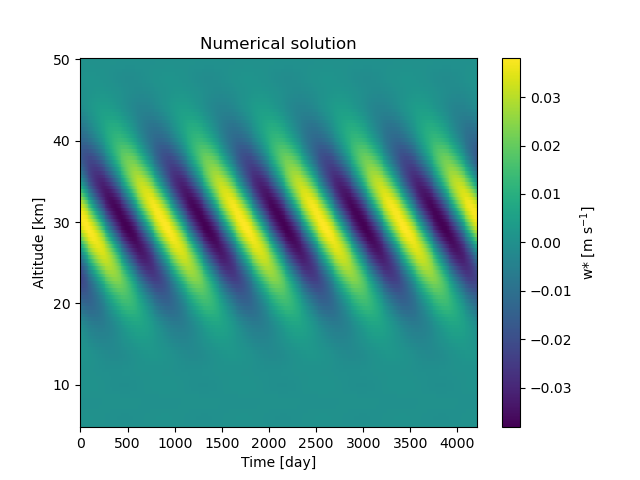

In [11]:
zt_plot(soln.T,
        title = 'Numerical solution',
        cbar_title = 'w* [m s$^{-1}$]',
        save = True,
        save_title = 'numerical_soln_N%s'%N
       )

In [12]:
def analytic_soln(opt):
    B = R * S0 / (H * C * C)
    
    
    # (Modified) forcing f = - stuff * dF/dz
    f = lambda z, t: -(C*H/R) * QBO_F * np.exp(-np.power(z-QBO_z0, 2) / (2 * np.power(QBO_dz, 2))) * ( 
                                    -((z-QBO_z0)/np.power(QBO_dz, 2)) * np.cos(m*z + QBO_omega*t) - m*np.sin(m*z + QBO_omega*t))
    
    # Forcing F
    curly_F = lambda z, t: QBO_F * np.exp(-np.power(z-QBO_z0, 2) / (2 * np.power(QBO_dz, 2))) * np.cos(m*z + QBO_omega*t)
    
    if opt == 0:
        int_func = lambda u, z, t: np.sqrt(1/B) * np.sin(np.sqrt(B) * (z - u)) * f(u, t)
        
        inte = lambda z, t: integrate.quad(int_func, z0, z, args=(z, t,))
        
        w = lambda z, t: -np.sin(np.sqrt(B)*(z-z0)) * inte(z1, t)[0] / np.sin(np.sqrt(B)*(z1-z0)) + inte(z, t)[0]
        
    elif opt == 1:
        int1_func = lambda u, t: np.sqrt(1/B) * np.sin(np.sqrt(B) * (u-z0)) * f(u, t)
        int2_func = lambda u, t: np.sqrt(1/B) * np.cos(np.sqrt(B) * (u-z0)) * f(u, t)
        
        int1 = lambda z, t: integrate.quad(int1_func, z0, z, args=(t,))
        int2 = lambda z, t: integrate.quad(int2_func, z0, z, args=(t,))
        
        D = lambda t: int1(z1, t)[0] / np.tan(np.sqrt(B) * (z1 - z0)) - int2(z1, t)[0]
        
        w = lambda z, t: D(t) * np.sin(np.sqrt(B) * (z-z0)) - np.cos(np.sqrt(B) * (z-z0)) * int1(z, t)[0] + np.sin(np.sqrt(B) * (z-z0)) * int2(z, t)[0]
        
    elif opt == 2:
        int1_func = lambda u, t: np.cos(np.sqrt(B)*(u - z0)) * curly_F(u, t)
        int2_func = lambda u, t: np.cos(np.sqrt(B)*(z1 - u)) * curly_F(u, t)
    
        int1 = lambda z, t: integrate.quad(int1_func, z0, z, args=(t,))
        int2 = lambda z, t: integrate.quad(int2_func, z, z1, args=(t,))
    
        w = lambda z, t: (C * H / (R * np.sin(np.sqrt(B) * (z1 - z0)))) * (
            -np.sin(np.sqrt(B)*(z1-z))*int1(z, t)[0] + np.sin(np.sqrt(B)*(z-z0))*int2(z, t)[0]
        )
        
    w_soln = np.zeros(shape=(len(ts), len(zs)))
    
    for i in range(len(ts)):
        for j in range(len(zs)):
            w_soln[i, j] = w(zs[j], ts[i])

    return w_soln

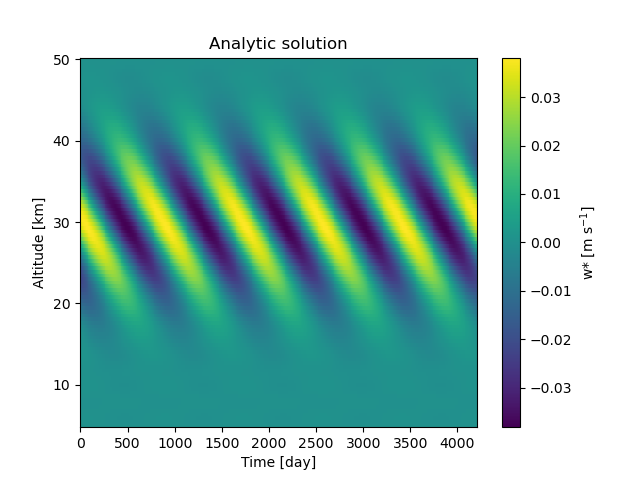

In [14]:
an_soln = analytic_soln(2)

zt_plot(an_soln,
        title = 'Analytic solution',
        cbar_title = 'w* [m s$^{-1}$]',
        save = True,
        save_title = 'analytic_soln',
       )

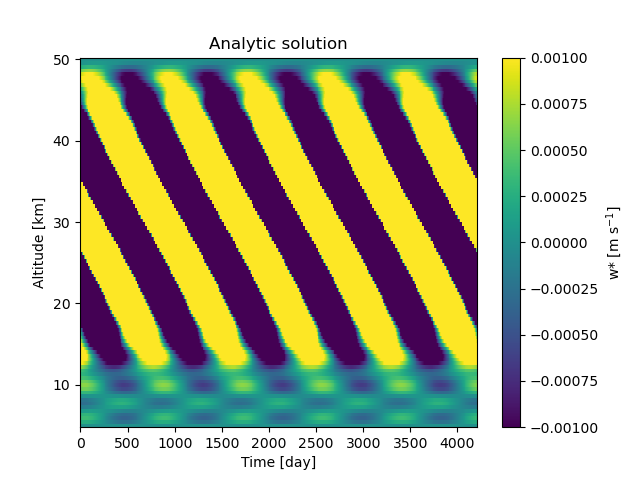

In [15]:
zt_plot(an_soln,
        title = 'Analytic solution',
        cbar_title = 'w* [m s$^{-1}$]',
        vmin = -1e-3,
        vmax = 1e-3
       )

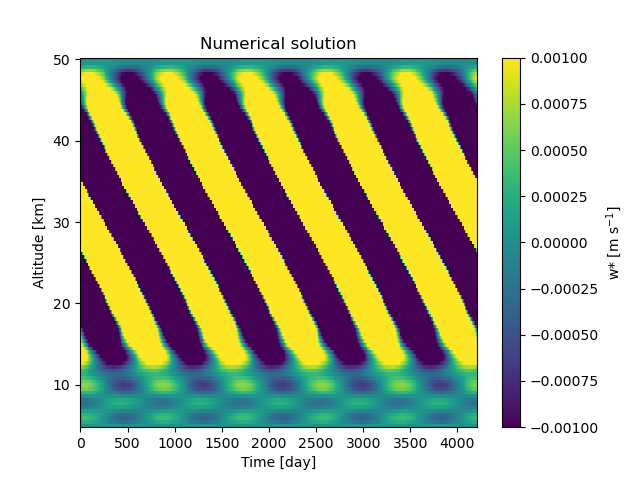

In [16]:
zt_plot(soln.T,
        title = 'Numerical solution',
        cbar_title = 'w* [m s$^{-1}$]',
        vmin = -1e-3,
        vmax = 1e-3
       )

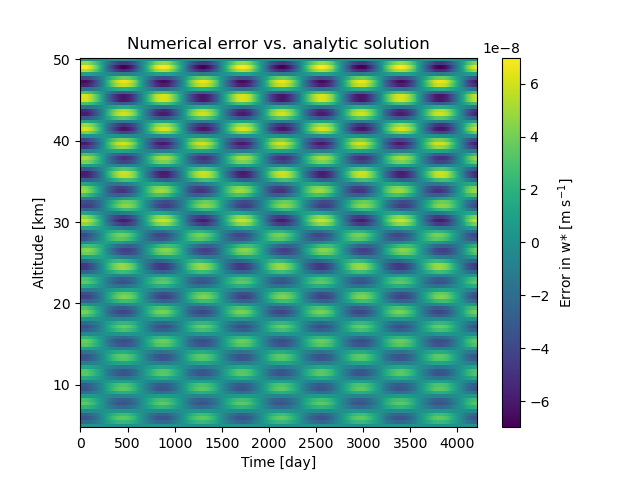

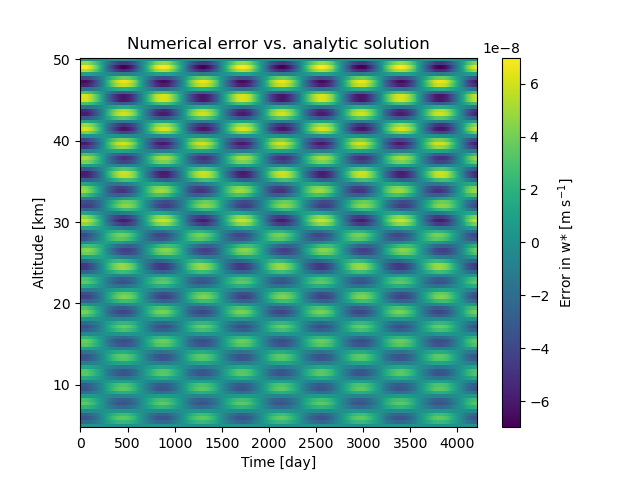

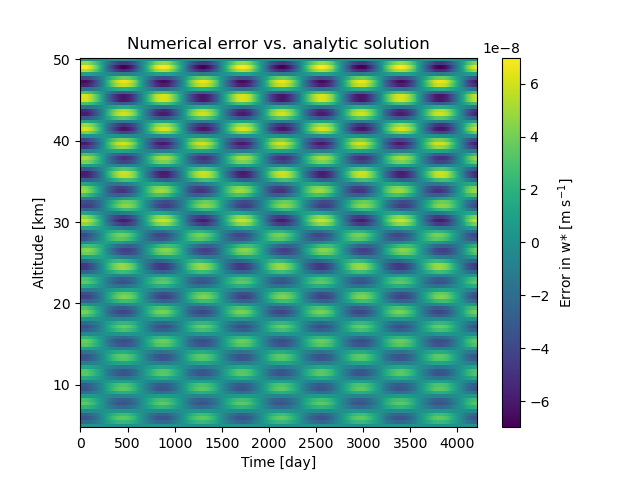

In [17]:
for opt in [0, 1, 2]:
    zt_plot(soln.T - analytic_soln(opt),
            title = 'Numerical error vs. analytic solution',
            cbar_title = 'Error in w* [m s$^{-1}$]',
            save = True,
            save_title='error_N%s_opt%s'%(N,opt)
           )